# Fase 1: Problem Definition

Formalização das definições de problema para aplicação de Knowledge Tracing ao dataset CSEDM (ProgSnap2 v6). Este notebook documenta os artefatos da Fase 1 do processo EDM e não realiza análise exploratória (ver `01_eda.ipynb`).

## Contexto do Projeto

Este TCC 1 aplica Educational Data Mining (EDM) ao dataset CSEDM para comparar três modelos de Knowledge Tracing: BKT (Bayesian Knowledge Tracing), DKT (Deep Knowledge Tracing) e Code-DKT (com representação de código via srcML). O objetivo é justificar a escolha do modelo base para o TCC 2, onde será desenvolvida uma ferramenta de suporte à aprendizagem.

A metodologia adotada é o EDM Process de 4 fases:

1. **Problem Definition** (este notebook)
2. **Data Preparation** (notebooks 01-03b)
3. **Modelling and Evaluation** (notebooks 04-07)
4. **Deployment** (diferido ao TCC 2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
DATA_ROOT = Path('../data/CSEDM')

## 1. Knowledge Components (KCs)

**Contexto:** A granularidade do KC define o que o modelo rastreia e determina a estrutura de treinamento. KC=ProblemID permite rastrear proficiência por problema individual, com um modelo treinado de forma independente por assignment — mesmo protocolo de Shi et al. (2022). Esta seção mapeia os assignments disponíveis e quantifica ProblemIDs por assignment para confirmar a viabilidade do protocolo.
**Hipótese:** O dataset deve conter os 5 assignments de Shi et al. (2022), cada um com ~10 ProblemIDs, confirmando que treinar um modelo por assignment com KC=ProblemID é viável com o volume de dados disponível.
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

Um Knowledge Component representa uma unidade de conhecimento ou habilidade que o modelo de KT rastreia. A definição adotada neste projeto é:

- **KC = ProblemID**: cada problema individual dentro de um assignment é uma unidade de conhecimento distinta.
- **Um modelo por assignment**: os 5 assignments definem 5 grupos de treinamento independentes. Dentro de cada grupo, os ~10 ProblemIDs são os KCs rastreados pelo modelo.
- **Fonte**: Shi et al. (2022), footnote 1 — *"We use problemIDs for KCs in this work"*.

Esta definição é consistente com o paper Code-DKT (Shi et al., 2022) e com a extensão srcML-DKT (Pankiewicz, Shi & Baker, 2025). Treinar um modelo por assignment (em vez de um único modelo global) evita contaminação cross-assignment e replica o protocolo experimental dos papers de referência.

In [2]:
early = pd.read_csv(DATA_ROOT / 'All/early.csv')
late  = pd.read_csv(DATA_ROOT / 'All/late.csv')


def kc_summary(df, arquivo):
    return (
        df.groupby('AssignmentID')['ProblemID']
        .nunique()
        .rename('ProblemIDs (KCs)')
        .to_frame()
        .assign(Arquivo=arquivo)
        .reset_index()
    )


kc_table = pd.concat(
    [kc_summary(early, 'early.csv'), kc_summary(late, 'late.csv')],
    ignore_index=True
)
kc_table.insert(0, 'Modelo', [f'Modelo A{i+1}' for i in range(len(kc_table))])

print('5 assignments → 5 modelos independentes (KC = ProblemID):\n')
print(kc_table.to_string(index=False))
print(f'\nTotal de KCs: {kc_table["ProblemIDs (KCs)"].sum()} ProblemIDs')

5 assignments → 5 modelos independentes (KC = ProblemID):

   Modelo  AssignmentID  ProblemIDs (KCs)   Arquivo
Modelo A1           439                10 early.csv
Modelo A2           487                10 early.csv
Modelo A3           492                10 early.csv
Modelo A4           494                10  late.csv
Modelo A5           502                10  late.csv

Total de KCs: 50 ProblemIDs


**Achado:** O dataset contém exatamente 5 assignments (IDs: 439, 487, 492, 494, 502), todos com 10 ProblemIDs cada — totalizando 50 KCs distribuídos entre `early.csv` (assignments 439, 487, 492) e `late.csv` (assignments 494, 502).
**Implicação para modelagem:** A distribuição uniforme de 10 ProblemIDs por assignment confirma o protocolo de Shi et al. (2022): 5 modelos independentes, um por assignment, com KC=ProblemID como unidade de rastreamento. O DKT base usa input one-hot de dimensão `2 × 10` (problem_id × correctness) por tentativa; o Code-DKT adiciona o vetor de representação de código concatenado a cada passo LSTM. Treinar modelos separados por assignment é essencial — sem isso, o modelo poderia confundir habilidades de assignments distintos.

## 2. Task de Knowledge Tracing

**Entrada:** histórico de tentativas de um estudante em um KC específico, representado como sequência de pares `(ProblemID, correto/errado)` até o instante `t`.

**Saída:** probabilidade de acerto na próxima tentativa `t+1`.

**Label binária:** `Label = True` indica que o estudante resolveu o problema dentro do número de tentativas alocadas; `Label = False` indica que não resolveu.

Os arquivos `early.csv` e `late.csv` fornecem os labels-alvo para avaliação dos modelos:
- `early.csv`: predição antecipada (assignments 1-3, primeiros dois meses do semestre)
- `late.csv`: predição tardia (assignments 4-5, último mês do semestre)

## 3. Splits do Dataset

**Contexto:** A escolha do split determina a reprodutibilidade comparativa. O CSEDM tem dois semestres independentes — All (Fall 2019, ~506 estudantes) e Release (Spring 2019, ~329 estudantes). Usar Release é obrigatório para comparar AUC com Shi et al. (2022). Os arquivos `early.csv`/`late.csv` fornecem labels de conclusão de assignment, distintos da taxa de tentativas corretas individuais usada nos modelos de KT.
**Hipótese:** O split Release/Train deve apresentar ~23.68% de tentativas corretas (benchmark de reprodutibilidade de Shi et al., 2022). O Label em early/late.csv (~74% True) representará conclusão de assignment — distinto das ~23.7% de tentativas corretas.
**Referência:** Shi et al. (2022); Price et al. (2020).

O dataset CSEDM possui vários splits. Para reprodutibilidade, os modelos serão avaliados no split **Release**, que corresponde à população reportada no paper Code-DKT (Shi et al., 2022).

| Split | Estudantes | Período | Finalidade |
|---|---|---|---|
| `Release/Train` | ~329 | fev-mai 2019 | Treinamento e validação dos modelos |
| `Release/Test`  | ~329 | fev-mai 2019 | Avaliação final (held-out) |
| `All` | ~506 | set-dez 2019 | EDA e análise exploratória |
| `Train` / `Test` | ~506 | set-dez 2019 | Alternativa (população maior) |

As populações `Release` e `All` não se sobrepõem (semestres distintos). O split `Release/Train` reproduz a estatística do paper: 23.70% de tentativas corretas vs. 23.68% reportados.

In [3]:
for nome, df in [('early.csv', early), ('late.csv', late)]:
    dist = df['Label'].value_counts(normalize=True).mul(100).round(2)
    print(f'{nome}: {len(df):,} registros')
    print(df.head(3).to_string(index=False))
    print('Distribuição do Label (%):')
    print(dist.to_string())
    print()

early.csv: 14,317 registros
                                                       SubjectID  AssignmentID  ProblemID  Attempts  CorrectEventually  Label
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           439          1         1               True   True
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           439          3         4               True   True
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           439          5         3               True   True
Distribuição do Label (%):
Label
True     73.91
False    26.09

late.csv: 9,386 registros
                                                       SubjectID  AssignmentID  ProblemID  Attempts  CorrectEventually  Label
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           494         41         2               True   True
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           494         43        17               True  False


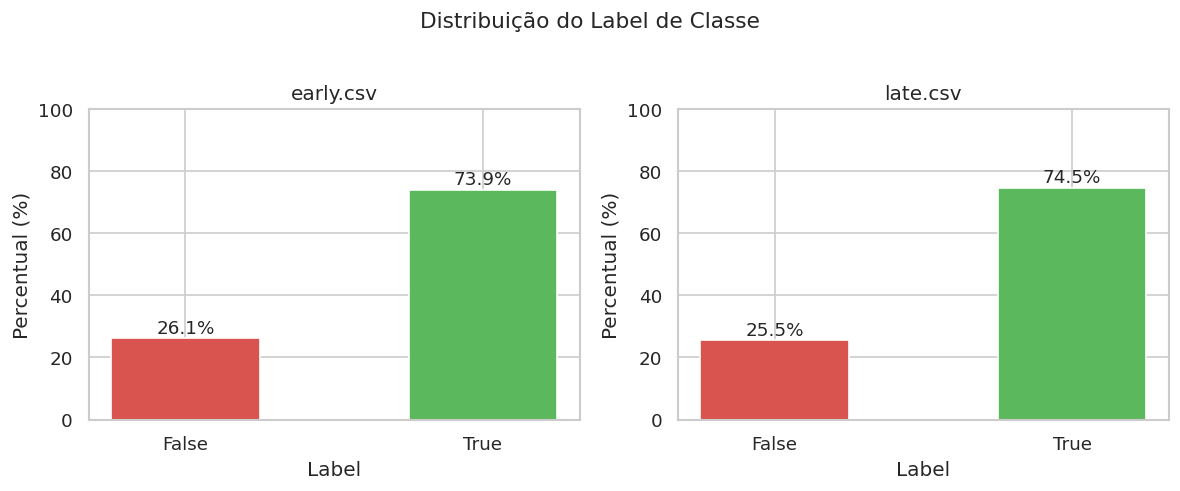

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (nome, df) in zip(axes, [('early.csv', early), ('late.csv', late)]):
    counts = df['Label'].value_counts(normalize=True).mul(100).sort_index()
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=['#d9534f', '#5cb85c'],
        edgecolor='white',
        width=0.5
    )
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11
        )
    ax.set_title(nome, fontsize=12)
    ax.set_xlabel('Label')
    ax.set_ylabel('Percentual (%)')
    ax.set_ylim(0, 100)

fig.suptitle('Distribuição do Label de Classe', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Achado:** Os arquivos de label mostram desbalanceamento moderado: `early.csv` tem 73.91% True / 26.09% False (14.317 registros) e `late.csv` tem 74.52% True / 25.48% False (9.386 registros). A taxa ~74% de sucesso (Label=True) refere-se à conclusão do assignment — é distinta da taxa de tentativas corretas individuais (~23.7% no split Release), que é a variável-alvo dos modelos de KT.
**Implicação para modelagem:** O desbalanceamento (~26% False) tornaria a acurácia enganosa (baseline trivial ≈ 74% ao prever sempre True). AUC-ROC é a métrica primária por ser threshold-independent e diretamente comparável com Shi et al. (2022). O split All (Fall 2019) é usado apenas para EDA; a avaliação final usa exclusivamente Release.

## 4. Métricas de Avaliação

**Contexto:** O protocolo de avaliação determina a validade da comparação entre modelos. Em KT para programação, existem duas métricas baseadas em AUC que medem aspectos complementares do desempenho preditivo: *first-attempt AUC* (predição na primeira tentativa de cada estudante em cada problema) e *all-attempts AUC* (todas as tentativas). A escolha da métrica primária afeta diretamente a comparabilidade com a literatura e a susceptibilidade a artefatos estatísticos — em particular, autocorrelação temporal quando o mesmo par (estudante, problema) gera múltiplas observações.
**Hipótese:** A maioria dos pares (estudante, problema) deve ter mais de 1 tentativa, o que torna autocorrelação uma preocupação concreta e justifica o uso de first-attempt AUC como métrica primária conforme Shi et al. (2022). O dataset é desbalanceado (~23.7% de tentativas corretas), tornando AUC mais informativo que acurácia.
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022); Piech et al. (2015).

Distribuição de tentativas por par (estudante, problema):
count    23703.000000
mean         5.102645
std          7.247279
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max        177.000000

Pares com exatamente 1 tentativa : 35.4%
Pares com mais de 1 tentativa    : 64.6%
Mediana de tentativas            : 2
Máximo de tentativas             : 177


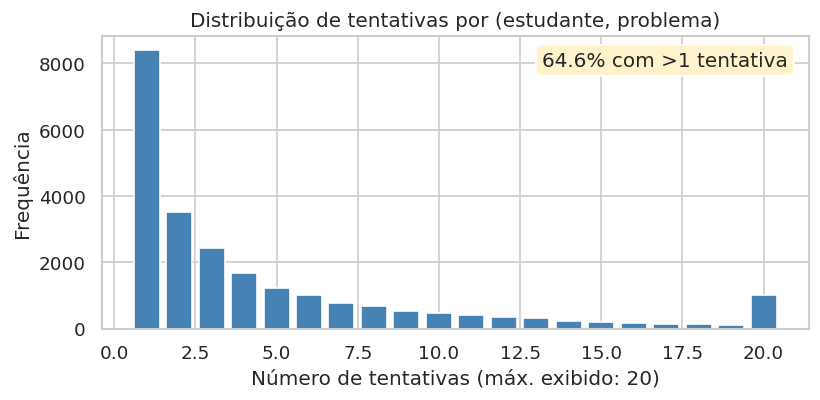

In [5]:
attempts_combined = pd.concat(
    [early[['SubjectID', 'AssignmentID', 'ProblemID', 'Attempts']],
     late[['SubjectID', 'AssignmentID', 'ProblemID', 'Attempts']]],
    ignore_index=True
)

desc = attempts_combined['Attempts'].describe()
multi_pct = (attempts_combined['Attempts'] > 1).mean() * 100
single_pct = 100 - multi_pct

print('Distribuição de tentativas por par (estudante, problema):')
print(desc.to_string())
print(f'\nPares com exatamente 1 tentativa : {single_pct:.1f}%')
print(f'Pares com mais de 1 tentativa    : {multi_pct:.1f}%')
print(f'Mediana de tentativas            : {desc["50%"]:.0f}')
print(f'Máximo de tentativas             : {desc["max"]:.0f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
clip = attempts_combined['Attempts'].clip(upper=20)
counts = clip.value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de tentativas (máx. exibido: 20)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de tentativas por (estudante, problema)')
ax.text(0.97, 0.95, f'{multi_pct:.1f}% com >1 tentativa',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd'))
plt.tight_layout()
plt.show()

**Achado:** 64.6% dos pares (estudante, problema) têm mais de 1 tentativa; mediana = 2 tentativas; máximo = 177. A distribuição é fortemente assimétrica à direita: muitos estudantes re-tentam problemas repetidamente antes de acertar.
**Implicação para modelagem:** Duas métricas complementares são adotadas, seguindo o protocolo de Shi et al. (2022):

- **First-attempt AUC** *(métrica primária)*: avalia a predição na *primeira* tentativa de cada estudante em cada problema. Elimina autocorrelação temporal — tentativas subsequentes do mesmo par (estudante, problema) são estatisticamente dependentes, inflando artificialmente o AUC se incluídas. É a métrica reportada na Table 2 de Shi et al. (2022) e é obrigatória para comparação direta com os resultados do paper.

- **All-attempts AUC** *(métrica secundária)*: avalia sobre *todas* as tentativas. Produz estimativas mais estáveis estatisticamente (maior N), e é comparável com a literatura DKT geral — Piech et al. (2015) reportam resultados neste formato (Table 1 de Shi et al., 2022). Reportada para complementar a comparação com a literatura mais ampla, mas não usada como critério de seleção de modelo.

A acurácia simples é descartada: com ~23.7% de corretos no split Release, um classificador trivial que sempre prediz "incorreto" atingiria ~76% de acurácia sem nenhum poder preditivo real.

## 5. Pergunta de Pesquisa

> KCs gerados de forma automática via análise de AST (srcML) + inferência de LLM melhoram a capacidade preditiva (AUC) dos modelos de Knowledge Tracing em relação ao baseline KC = AssignmentID?

## 6. Resumo das Decisões de Modelagem

Tabela consolidada de todas as decisões tomadas neste notebook e seus fundamentos:

| Decisão | Valor | Justificativa |
|---------|-------|---------------|
| **Knowledge Component (KC)** | `ProblemID` — 10 KCs por assignment | Shi et al. (2022), footnote 1: cada problema é unidade de conhecimento distinta; 5 modelos independentes evitam contaminação cross-assignment |
| **Estrutura de treinamento** | 1 modelo por assignment | Replicar protocolo de Shi et al. (2022); DKT input `2 × 10` (problem × correctness); Code-DKT adiciona vetor de código ao LSTM |
| **Split de avaliação** | `Release/Train` / `Release/Test` (Spring 2019, ~329 estudantes) | Única forma de comparar AUC com resultados de Shi et al. (2022); `All` (Fall 2019) reservado para EDA |
| **Métrica primária** | **First-attempt AUC** | Elimina autocorrelação temporal (64.6% dos pares têm >1 tentativa); diretamente comparável com Table 2 de Shi et al. (2022) |
| **Métrica secundária** | **All-attempts AUC** | Maior N → estimativas mais estáveis; comparável com literatura DKT geral (Piech et al., 2015; Table 1 de Shi et al., 2022) |
| **Labels-alvo** | `early.csv` / `late.csv`, coluna `Label` | Indicadores de conclusão de assignment (binários); distintos da taxa de tentativas corretas usada no KT |
| **Threshold de acerto (KT)** | `Score == 1.0` para `Run.Program` | ~37% dos registros têm score parcial; threshold binário compatível com BKT/DKT/Code-DKT |
| **Inclusão de Compile.Error** | `correct=0` na sequência (Code-DKT / srcML-DKT) | 30.27% dos eventos; srcML parseia código não-compilável; protocolo de Pankiewicz, Shi & Baker (2025) |
| **Truncamento de sequências** | Últimas 50 tentativas por (estudante, assignment) | Protocolo de Shi et al. (2022); descarta histórico mais antigo em outliers (máx. 177 tentativas) |
| **Seed fixo** | 42 | Reprodutibilidade obrigatória em todos os notebooks |